# Loan Default Prediction with Explainable AI (XAI)

- Load and explore a loan default dataset
- Preprocess and engineer features
- Handle class imbalance
- Train ML models (Logistic Regression, Random Forest, XGBoost/LightGBM)
- Evaluate using ROC-AUC, F1, confusion matrix
- Use SHAP (and optionally LIME) to explain global and local predictions


In [88]:
# loan-default-prediction

# 2. Install & Import Libraries

In [89]:
!pip install pandas numpy scikit-learn xgboost shap imbalanced-learn seaborn lightgbm fairlearn
# pip install fairlearn

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap
from fairlearn.metrics import MetricFrame, false_positive_rate
import sklearn.metrics as metrics
import joblib


# 3. Load the Lending Club Dataset

In [91]:
df = pd.read_csv("loans_full_schema.csv", low_memory=False)
df.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


# 4. EDA (Exploratory Data Analysis)
- What are the columns
- 

In [95]:
df.shape

(10000, 55)

In [93]:
df.columns

Index(['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income',
       'verified_income', 'debt_to_income', 'annual_income_joint',
       'verification_income_joint', 'debt_to_income_joint', 'delinq_2y',
       'months_since_last_delinq', 'earliest_credit_line',
       'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines',
       'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'public_record_bankr

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

In [98]:
# Check for missiing values
df_is_null = df.isnull().sum()
print(df_is_null)

emp_title                            833
emp_length                           817
state                                  0
homeownership                          0
annual_income                          0
verified_income                        0
debt_to_income                        24
annual_income_joint                 8505
verification_income_joint           8545
debt_to_income_joint                8505
delinq_2y                              0
months_since_last_delinq            5658
earliest_credit_line                   0
inquiries_last_12m                     0
total_credit_lines                     0
open_credit_lines                      0
total_credit_limit                     0
total_credit_utilized                  0
num_collections_last_12m               0
num_historical_failed_to_pay           0
months_since_90d_late               7715
current_accounts_delinq                0
total_collection_amount_ever           0
current_installment_accounts           0
accounts_opened_

In [99]:
# df.describe()

# 5. Target Variable Engineering

Lending Club uses loan_status with values like:
- Current
- Fully Paid
- Charged Off
- In Grace Period
- Late (16–30 days)
- Late (31–120 days)

In [101]:
No of unique values
df['loan_status'].nunique()

6

In [102]:
df['loan_status'].unique().tolist()


['Current',
 'Fully Paid',
 'In Grace Period',
 'Late (31-120 days)',
 'Charged Off',
 'Late (16-30 days)']

In [105]:
df['loan_status'].value_counts()


loan_status
Current               9375
Fully Paid             447
In Grace Period         67
Late (31-120 days)      66
Late (16-30 days)       38
Charged Off              7
Name: count, dtype: int64

In [106]:
# default count
df['default'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)
df['default'].value_counts()

default
0    9993
1       7
Name: count, dtype: int64

In [107]:
# We convert to binary and normalize
df['default'].value_counts(normalize=True)

default
0    0.9993
1    0.0007
Name: proportion, dtype: float64

In [141]:
# Select all numeric columns (int64 and float types)
numeric_features = df.select_dtypes(include=['int64', 'float'])
feature_list = numeric_features.columns.tolist()

In [142]:
# average_values 
average_values = df[feature_list].mean()
print(f"Average values: \n{average_values}")

Average values: 
emp_length                               5.930306
annual_income                        79222.148412
debt_to_income                          19.308192
annual_income_joint                 127914.571244
debt_to_income_joint                    19.979304
delinq_2y                                0.216000
months_since_last_delinq                36.760709
earliest_credit_line                  2001.290000
inquiries_last_12m                       1.958200
total_credit_lines                      22.679600
open_credit_lines                       11.404400
total_credit_limit                  183606.230400
total_credit_utilized                51049.063100
num_collections_last_12m                 0.013800
num_historical_failed_to_pay             0.167100
months_since_90d_late                   46.112473
current_accounts_delinq                  0.000100
total_collection_amount_ever           184.334000
current_installment_accounts             2.663600
accounts_opened_24m              

In [143]:
# Lets use these features/columns
features =  [ 
	'emp_length',
	'homeownership', 
	'annual_income',
    'verified_income', 
	'debt_to_income',  
	'delinq_2y',
    'inquiries_last_12m',
	'total_credit_utilized', 
	'open_credit_lines',
    'total_credit_limit',
    'public_record_bankrupt',
	'loan_purpose',
	'loan_amount', 
	'interest_rate', 
	'installment', 
	'grade', 
	'sub_grade', 
	'loan_status', 
	'balance'
    ]


In [144]:
print(f"Number of selected features: {len(features)}")

Number of selected features: 19


In [158]:
df[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   emp_length              9183 non-null   float64
 1   homeownership           10000 non-null  object 
 2   annual_income           10000 non-null  float64
 3   verified_income         10000 non-null  object 
 4   debt_to_income          9976 non-null   float64
 5   delinq_2y               10000 non-null  int64  
 6   inquiries_last_12m      10000 non-null  int64  
 7   total_credit_utilized   10000 non-null  int64  
 8   open_credit_lines       10000 non-null  int64  
 9   total_credit_limit      10000 non-null  int64  
 10  public_record_bankrupt  10000 non-null  int64  
 11  loan_purpose            10000 non-null  object 
 12  loan_amount             10000 non-null  int64  
 13  interest_rate           10000 non-null  float64
 14  installment             10000 non-null 

In [145]:
# Select all numeric columns (int64 and float types)
numeric_features = df[features].select_dtypes(include=['int64', 'float'])
feature_list = numeric_features.columns.tolist()
print(f"Number of selected Numeric features: {len(feature_list)}")

Number of selected Numeric features: 13


In [146]:
# average_values 
average_values = df[feature_list].mean()
print(f"Average values: \n{average_values}")

Average values: 
emp_length                     5.930306
annual_income              79222.148412
debt_to_income                19.308192
delinq_2y                      0.216000
inquiries_last_12m             1.958200
total_credit_utilized      51049.063100
open_credit_lines             11.404400
total_credit_limit        183606.230400
public_record_bankrupt         0.123800
loan_amount                16361.922500
interest_rate                 12.427524
installment                  476.205323
balance                    14458.916610
dtype: float64


In [147]:
df[feature_list].describe()

,emp_length,annual_income,debt_to_income,delinq_2y,inquiries_last_12m,total_credit_utilized,open_credit_lines,total_credit_limit,public_record_bankrupt,loan_amount,interest_rate,installment,balance
count,9183.000000,1.000000e+04,9976.000000,10000.00000,10000.00000,10000.000000,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.930306,7.922215e+04,19.308192,0.21600,1.95820,51049.063100,11.40440,1.836062e+05,0.123800,16361.922500,12.427524,476.205323,14458.916610
std,3.703734,6.473429e+04,15.004851,0.68366,2.38013,53636.731172,5.86828,1.876327e+05,0.337172,10301.956759,5.001105,294.851627,9964.561865
min,0.000000,0.000000e+00,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000e+00,0.000000,1000.000000,5.310000,30.750000,0.000000
25%,2.000000,4.500000e+04,11.057500,0.00000,0.00000,19185.500000,7.00000,5.159375e+04,0.000000,8000.000000,9.430000,256.040000,6679.065000
50%,6.000000,6.500000e+04,17.570000,0.00000,1.00000,36927.000000,10.00000,1.146670e+05,0.000000,14500.000000,11.980000,398.420000,12379.495000
75%,10.000000,9.500000e+04,25.002500,0.00000,3.00000,65421.000000,14.00000,2.675500e+05,0.000000,24000.000000,15.050000,644.690000,20690.182500
max,10.000000,2.300000e+06,469.090000,13.00000,29.00000,942456.000000,51.00000,3.386034e+06,3.000000,40000.000000,30.940000,1566.590000,40000.000000


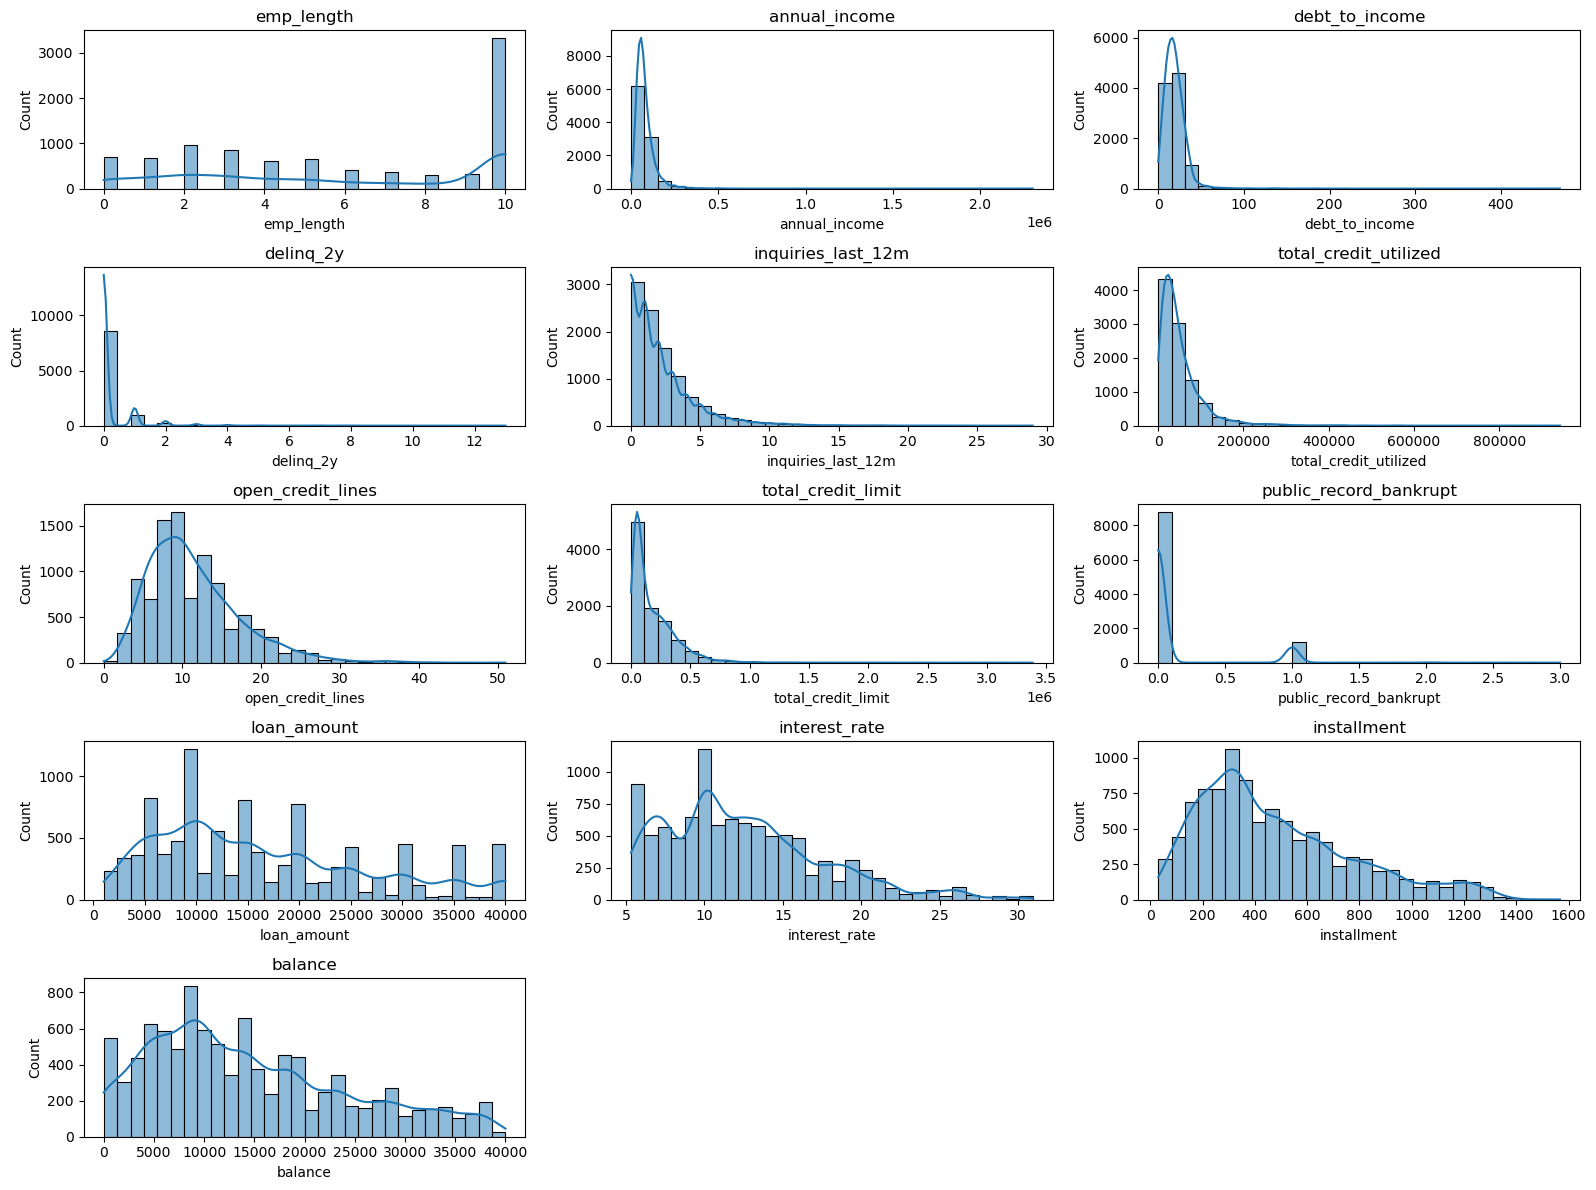

In [154]:
# Distribution Plots (Histograms + KDE)
# Using nuumeric featrues
plt.figure(figsize=(16, 12))
for i, col in enumerate(feature_list, 1):
    plt.subplot(5, 3, i) # 3 columns by 6 rows
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


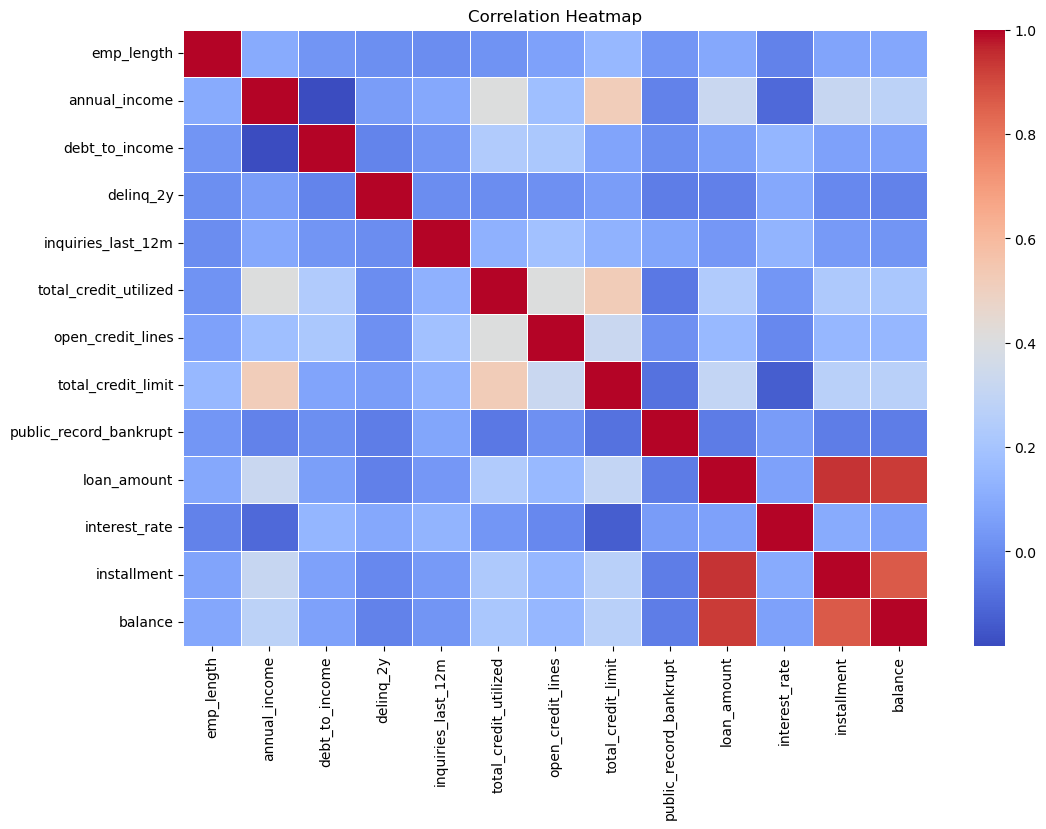

In [155]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df[feature_list].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


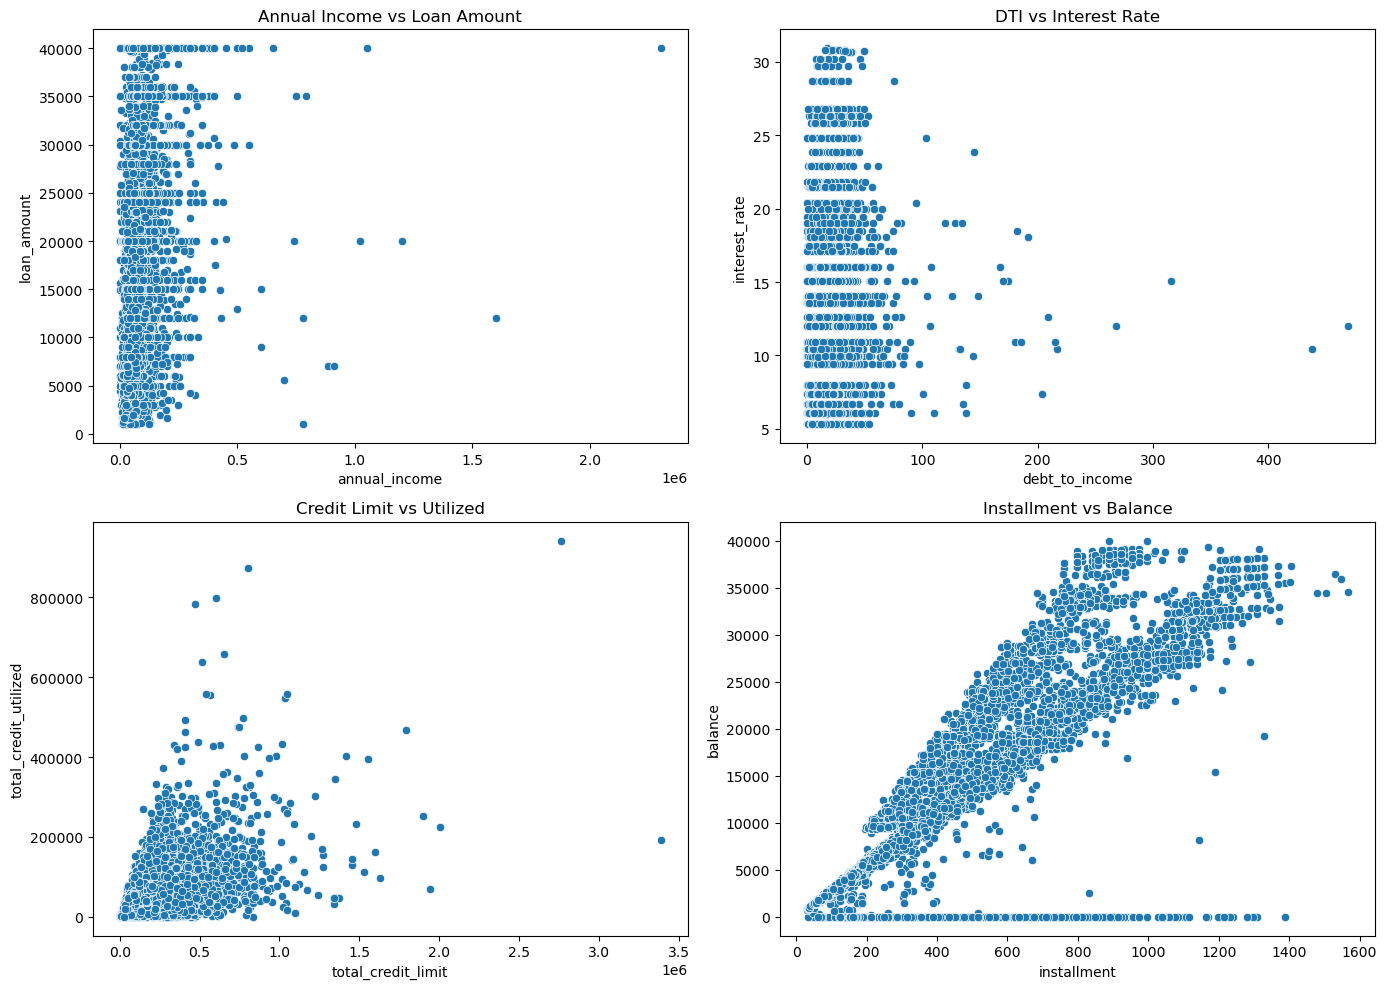

In [156]:
# Scatter Plots for Key Relationships
plt.figure(figsize=(14, 10))

# Income vs Loan Amount
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x="annual_income", y="loan_amount")
plt.title("Annual Income vs Loan Amount")

# Debt-to-Income vs Interest Rate
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x="debt_to_income", y="interest_rate")
plt.title("DTI vs Interest Rate")

# Credit Utilized vs Credit Limit
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x="total_credit_limit", y="total_credit_utilized")
plt.title("Credit Limit vs Utilized")

# Balance vs Installment
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x="installment", y="balance")
plt.title("Installment vs Balance")

plt.tight_layout()
plt.show()


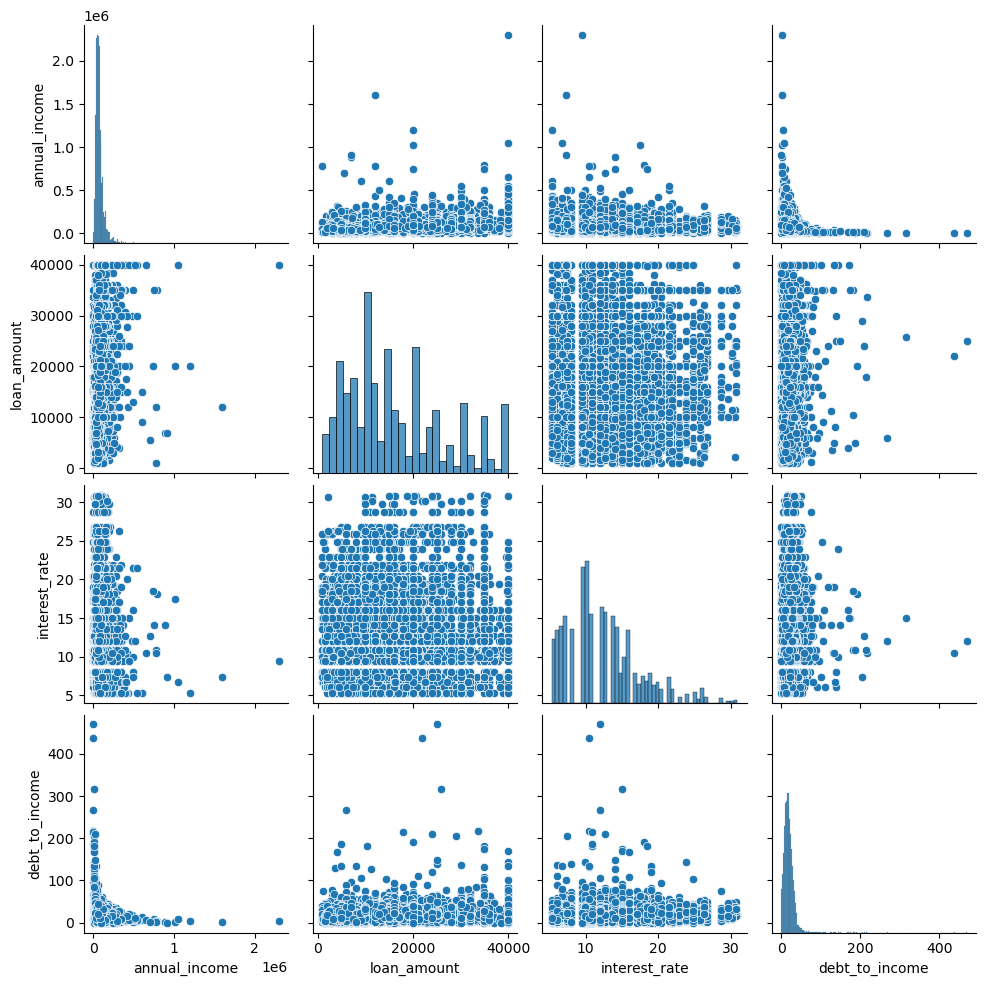

In [157]:
# Pairplot (Quick Multivariate Overview)
# Interactions bwtween variables
sns.pairplot(df[["annual_income", "loan_amount", "interest_rate", "debt_to_income"]])
plt.show()